# 01 — Exploration des alertes simulées

Objectif : comprendre la distribution des 80 alertes avant d'entraîner le modèle de détection d'anomalies (`IsolationForest`).

Données : `03_alertes_simulees.csv`

In [2]:
import os
print(os.getcwd())
print(os.path.exists("../../data/03_alertes_simulees.csv"))

c:\Users\Doua\Downloads\copilote-telecom-pour-repo\ml\notebooks
True


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

alertes = pd.read_csv("../../data/03_alertes_simulees.csv", sep=";")
print("Nombre d'alertes :", len(alertes))
alertes.head()


Matplotlib is building the font cache; this may take a moment.


Nombre d'alertes : 80


,external_alarm_id,source_system,date_alerte,code_site,code_equipement,code_service,type_alerte,severite,message,metrique,valeur_mesuree,seuil,unite,statut,fingerprint
0,SIM-0001,SIMULATEUR_STAGE,2026-06-17 23:36:39,TUN-POP-001,TUN-SRV-NMS-01,APP-OSS,RAM_HIGH,MINEURE,Mémoire RAM élevée : 77%,RAM,77,90,%,NOUVELLE,TUN-POP-001-TUN-SRV-NMS-01-RAM_HIGH
1,SIM-0002,SIMULATEUR_STAGE,2026-06-16 19:50:39,SOU-DC-001,SOU-SRV-OSS-01,APP-OSS,RAM_HIGH,MAJEURE,Mémoire RAM élevée : 88%,RAM,88,90,%,NOUVELLE,SOU-DC-001-SOU-SRV-OSS-01-RAM_HIGH
2,SIM-0003,SIMULATEUR_STAGE,2026-06-16 18:24:39,ARI-BTS-014,ARI-ENB-014,APP-OSS,RAM_HIGH,CRITIQUE,Mémoire RAM élevée : 86%,RAM,86,90,%,NOUVELLE,ARI-BTS-014-ARI-ENB-014-RAM_HIGH
3,SIM-0004,SIMULATEUR_STAGE,2026-06-18 20:17:39,SOU-DC-001,SOU-SRV-OSS-01,MW-BACKHAUL,LINK_DOWN,CRITIQUE,Lien de transmission indisponible,LINK_STATUS,0,1,etat,NOUVELLE,SOU-DC-001-SOU-SRV-OSS-01-LINK_DOWN
4,SIM-0005,SIMULATEUR_STAGE,2026-06-21 00:10:39,TUN-POP-001,TUN-RTR-CORE-01,APP-OSS,SERVICE_DOWN,CRITIQUE,Service applicatif arrêté,SERVICE_STATUS,0,1,etat,NOUVELLE,TUN-POP-001-TUN-RTR-CORE-01-SERVICE_DOWN


## Structure et valeurs manquantes

In [6]:
print(alertes.dtypes)
print()
print("Valeurs manquantes par colonne :")
print(alertes.isna().sum())

external_alarm_id      str
source_system          str
date_alerte            str
code_site              str
code_equipement        str
code_service           str
type_alerte            str
severite               str
message                str
metrique               str
valeur_mesuree       int64
seuil                int64
unite                  str
statut                 str
fingerprint            str
dtype: object

Valeurs manquantes par colonne :
external_alarm_id    0
source_system        0
date_alerte          0
code_site            0
code_equipement      0
code_service         0
type_alerte          0
severite             0
message              0
metrique             0
valeur_mesuree       0
seuil                0
unite                0
statut               0
fingerprint          0
dtype: int64


## Répartition par type d'alerte et par sévérité

type_alerte
LINK_DOWN             16
RAM_HIGH              14
CPU_HIGH              12
SERVICE_DOWN          11
POWER_FAIL             9
PING_LOSS              7
DISK_FULL              7
AUTH_FAILURE_SPIKE     4
Name: count, dtype: int64

severite
CRITIQUE    55
MAJEURE     13
MINEURE     12
Name: count, dtype: int64


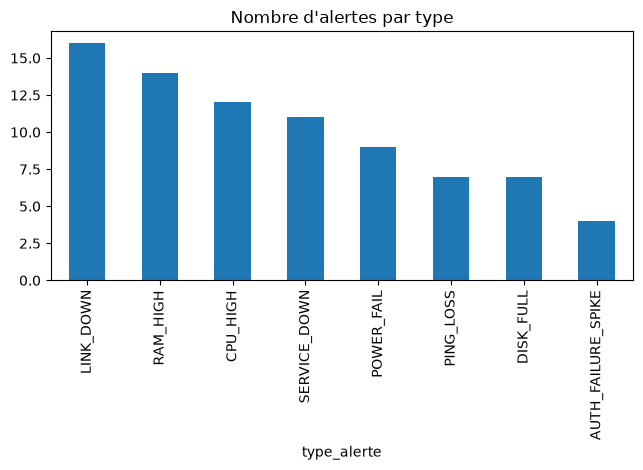

In [7]:
print(alertes['type_alerte'].value_counts())
print()
print(alertes['severite'].value_counts())

alertes['type_alerte'].value_counts().plot(kind='bar', title="Nombre d'alertes par type")
plt.tight_layout()
plt.show()

## Feature clé pour le modèle : ratio valeur_mesuree / seuil

C'est la feature la plus importante pour `IsolationForest` : elle met CPU%, RAM%, perte de paquets... sur
une même échelle comparable, quel que soit le type d'alerte.

count    80.000000
mean      0.605284
std       0.684152
min       0.000000
25%       0.000000
50%       0.844444
75%       0.977778
max       3.950000
Name: ratio_seuil, dtype: float64


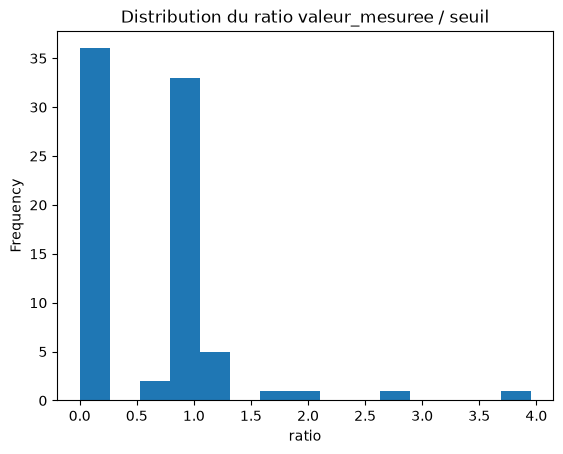

In [9]:
alertes['ratio_seuil'] = alertes['valeur_mesuree'] / alertes['seuil'].replace(0, 1)
print(alertes['ratio_seuil'].describe())

alertes['ratio_seuil'].plot(kind='hist', bins=15, title="Distribution du ratio valeur_mesuree / seuil")
plt.xlabel("ratio")
plt.show()

## Alertes déjà au-dessus du seuil (dépassement franc)

Ce sont probablement les alertes les plus "évidentes" — utile pour vérifier ensuite si le modèle
les détecte bien comme anormales.

In [10]:
alertes[alertes['ratio_seuil'] >= 1][
    ['external_alarm_id', 'type_alerte', 'severite', 'valeur_mesuree', 'seuil', 'ratio_seuil']
].sort_values('ratio_seuil', ascending=False)

,external_alarm_id,type_alerte,severite,valeur_mesuree,seuil,ratio_seuil
14,SIM-0015,AUTH_FAILURE_SPIKE,CRITIQUE,79,20,3.950000
23,SIM-0024,AUTH_FAILURE_SPIKE,MINEURE,55,20,2.750000
48,SIM-0049,AUTH_FAILURE_SPIKE,MINEURE,38,20,1.900000
34,SIM-0035,AUTH_FAILURE_SPIKE,MINEURE,34,20,1.700000
9,SIM-0010,PING_LOSS,CRITIQUE,95,80,1.187500
64,SIM-0065,CPU_HIGH,CRITIQUE,97,90,1.077778
71,SIM-0072,RAM_HIGH,CRITIQUE,97,90,1.077778
30,SIM-0031,RAM_HIGH,CRITIQUE,96,90,1.066667
21,SIM-0022,CPU_HIGH,CRITIQUE,95,90,1.055556
24,SIM-0025,RAM_HIGH,CRITIQUE,94,90,1.044444


## Conclusions à retenir pour la suite

- 80 alertes, 8 types (`CPU_HIGH`, `RAM_HIGH`, `DISK_FULL`, `LINK_DOWN`, `SERVICE_DOWN`, `PING_LOSS`,
  `POWER_FAIL`, `AUTH_FAILURE_SPIKE`), répartition à vérifier ci-dessus.
- Le ratio `valeur_mesuree / seuil` est la feature numérique la plus utile pour `IsolationForest`.
- Pas d'entraînement supervisé ici : on ne cherche pas à prédire `categorie` ou `severite`
  (ça, c'est le rôle du moteur de règles), seulement à repérer les comportements inhabituels.
- Prochaine étape : `02_evaluation.ipynb`, une fois qu'Emna a entraîné le modèle dans `ml/train_model.py`.